# Chapter 24: How Much Capability Have We Extracted?

A procedure succeeds more often in a supplied table. That is the beginning of an evaluation, not its conclusion. Were the same tasks used? Did both procedures receive the same opportunities? Is the target population mostly easy tasks, mostly difficult tasks, or the mixture that happened to be logged? A single average cannot answer those questions.

This laboratory begins with one row per observed procedure, task, and run. Those identifiers do real work. They define the denominator for each procedure and identify matched comparisons where both procedures attempted the same task/run pair. The table also records optional cost and exposure, so an observed subset cannot quietly become the denominator for the whole evaluation.

The example is small enough to inspect by hand. The candidate repairs one of the baseline's failures while leaving the other outcomes unchanged. Count those pairs before reading the rate bars. Then change the target task mixture without changing any observations. Finally try a transfer table with no overlap between procedures. The correct result there is an unavailable matched effect, not an invented zero and not a claim that the raw rate difference estimates improvement.

**Outcome:** Report observed denominators, matched differences, uncertainty assumptions, and target mixtures.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- Sample means and paired observations

## The question and its mathematics

For procedure p, the observed success rate is s_p/n_p, where n_p counts all supplied rows for that procedure and s_p counts true success flags. This denominator is explicit. Exposure-conditional rates use only exposed rows and have a different denominator. They describe that observed subset; they do not automatically estimate success in the target task population.

For a matched task/run pair i, define d_i=Y_candidate,i-Y_baseline,i. Each difference is -1, 0, or 1. The matched mean is sum_i d_i/m over the m common pairs. When m is at least two, the reported standard error is the sample standard deviation of those differences divided by sqrt(m). This formula requires independent representative pairs for its usual sampling interpretation. Matching identifiers alone does not establish randomization or causal attribution.

The Wilson interval is reported for each procedure's binary rate. With z approximately 1.96, its center is (p_hat+z^2/(2n))/(1+z^2/n), and its half-width accounts for both p_hat(1-p_hat)/n and z^2/(4n^2). The interval is conditional on a binomial sampling model, not a universal confidence statement about correlated repeated tasks.

A target mixture uses weights w_t that sum to one and task-specific observed rates p_hat_p,t. Its estimate is sum_t w_t p_hat_p,t only when every positively represented task has observations for that procedure. Missing cells remain unavailable. None of these averages identifies the probability that an entire long trajectory succeeds.

## A calculation you can run

Validate the records before computing rates. Procedure, task, and run identifiers must be nonempty strings, successes and exposure flags must be exact booleans, costs must be finite and nonnegative, and duplicate procedure/task/run rows are rejected. These requirements prevent accidental double counting and ambiguous pairing.

The computation groups rows by procedure, calculates denominators and rates, and then forms a separate intersection of task/run keys for the declared baseline and candidate. The matched difference uses that intersection alone. If it is empty, the difference and standard error are unavailable. With one matched pair, the point difference exists but sample standard error does not.

Task weights are an optional second input boundary. They must form a normalized probability distribution over named tasks. The code computes task-specific rates from the supplied rows and reweights them without altering the records. The rate chart shows observed procedure averages; the paired-difference chart shows the individual common-pair differences. Consult the table and metrics together so an impressive average does not erase a thin denominator, missing task cell, or different observation cost.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 24
inputs = {'baseline': 'base',
 'candidate': 'new',
 'records': [{'procedure': 'base',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '1',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'base',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '1',
              'success': True,
              'cost': 2,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 2,
              'exposed': True}],
 'task_weights': {'easy': 0.5, 'hard': 0.5}}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed teaching example

Calculated quantities:
{
  "procedures": {
    "base": {
      "n": 4,
      "successes": 2,
      "rate": 0.5,
      "wilson_interval_iid": [
        0.1500389892,
        0.8499610108
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.0
    },
    "new": {
      "n": 4,
      "successes": 3,
      "rate": 0.75,
      "wilson_interval_iid": [
        0.3006418426,
        0.9544127392
      ],
      "mean_cost": 2.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.5
    }
  },
  "matched_n": 4,
  "matched_difference": 0.25,
  "matched_standard_error_iid_pairs": 0.25,
  "task_mixture_rates": {
    "base": 0.5,
    "new": 0.75
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run identifiers

The baseline succeeds on two of four runs, giving 0.5. The candidate succeeds on three of four, giving 0.75. All four task/run identifiers match, so the paired differences are 0,1,0,0 and their mean is 0.25. Their sample standard error is 0.25 under independent-pair sampling. The small table supports a descriptive matched improvement; it is not precise evidence of a deployment guarantee.

Easy-task rates are 1 for both procedures. Hard-task rates are 0 for the baseline and 0.5 for the candidate. Equal target weights reproduce 0.5 and 0.75. When the target mixture assigns 0.9 to hard tasks, the reweighted rates become 0.1 and 0.55. The observations did not change. The estimand did. Preserve that distinction when presenting the changed-case figure.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


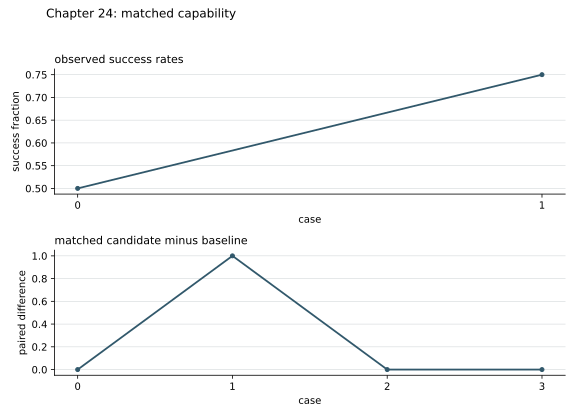

In [3]:
display(SVG(figure_svg(report)))

**Figure 24.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Repeated attempts can make a procedure's average look more certain than the task evidence warrants. Four runs on one task are not automatically equivalent to four independent tasks from a population. If failures share a document, environment state, or procedure configuration, the binomial and independent-pair uncertainty formulas can be too optimistic. Their names in the output keep those assumptions visible.

Another failure occurs when an observed subset is treated as the target population. Exposure may select difficult cases, favorable cases, or runs where a monitor was available. An exposure-conditional rate is useful only for its declared subset unless a sampling design justifies transport. The denominator should be reported beside the rate, including zero exposed observations as an unavailable conditional rate.

The transfer fixture contains different task/run keys for the two procedures. The raw rates still exist, but no matched difference can be calculated. Missing cells also prevent the proposed equal-task mixture from being estimated. Returning zero would falsely imply no difference; borrowing another procedure's outcome would fabricate evidence. The useful next step is to run both procedures on the missing matched tasks under the same evaluation contract.

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "procedures": {
    "base": {
      "n": 4,
      "successes": 2,
      "rate": 0.5,
      "wilson_interval_iid": [
        0.1500389892,
        0.8499610108
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.0
    },
    "new": {
      "n": 4,
      "successes": 3,
      "rate": 0.75,
      "wilson_interval_iid": [
        0.3006418426,
        0.9544127392
      ],
      "mean_cost": 2.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.5
    }
  },
  "matched_n": 4,
  "matched_difference": 0.25,
  "matched_standard_error_iid_pairs": 0.25,
  "task_mixture_rates": {
    "base": 0.1,
    "new": 0.55
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run i

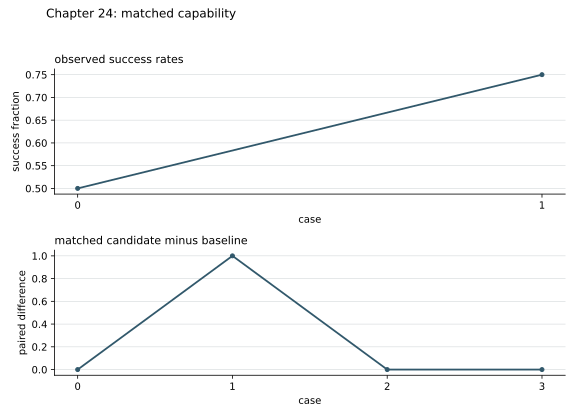

In [4]:
changed_inputs = {'baseline': 'base',
 'candidate': 'new',
 'records': [{'procedure': 'base',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '1',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'base',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '1',
              'success': True,
              'cost': 2,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 2,
              'exposed': True}],
 'task_weights': {'easy': 0.1, 'hard': 0.9}}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 24.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

Apply this method to compatible local records by keeping the sampling unit explicit. If a run identifier denotes a random seed, environment instance, or attempt number, document that meaning before comparing procedures. Choose the success predicate before examining outcomes, and preserve costs even when they complicate an appealing success-rate story.

The transfer table demonstrates the missing-data boundary. Its old procedure has one success on alpha, while the proposal has one failure on beta. That is insufficient for a matched comparison or a two-task target estimate. Export a measurement request that names the missing alpha/proposal and beta/old cells. When the data are supplied, recompute the matched and mixture quantities. Avoid converting a procedure average into a per-step reliability law; trajectory completion needs run-level evidence or a declared conditional process.

In [5]:
transfer_inputs = {'baseline': 'old',
 'candidate': 'proposal',
 'records': [{'procedure': 'old',
              'task': 'alpha',
              'run': 'one',
              'success': True,
              'cost': 1},
             {'procedure': 'proposal',
              'task': 'beta',
              'run': 'two',
              'success': False,
              'cost': 3}],
 'task_weights': {'alpha': 0.5, 'beta': 0.5}}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed transfer example

Calculated quantities:
{
  "procedures": {
    "old": {
      "n": 1,
      "successes": 1,
      "rate": 1.0,
      "wilson_interval_iid": [
        0.2065493144,
        1
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    },
    "proposal": {
      "n": 1,
      "successes": 0,
      "rate": 0.0,
      "wilson_interval_iid": [
        0,
        0.7934506856
      ],
      "mean_cost": 3.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    }
  },
  "matched_n": 0,
  "matched_difference": null,
  "matched_standard_error_iid_pairs": null,
  "task_mixture_rates": {
    "old": null,
    "proposal": null
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run identifiers; missing pa

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **baseline:** Observed baseline procedure identifier.
- **candidate:** Observed distinct candidate procedure identifier.
- **records:** List of records with procedure,task,run:string and success:exact boolean; optional cost:nonnegative number, exposed:exact boolean. Procedure/task/run must be unique.
- **task_weights:** Optional object of task identifiers to normalized probabilities defining a target mixture.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch24.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "procedures": {
    "old": {
      "n": 1,
      "successes": 1,
      "rate": 1.0,
      "wilson_interval_iid": [
        0.2065493144,
        1
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    },
    "proposal": {
      "n": 1,
      "successes": 0,
      "rate": 0.0,
      "wilson_interval_iid": [
        0,
        0.7934506856
      ],
      "mean_cost": 3.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    }
  },
  "matched_n": 0,
  "matched_difference": null,
  "matched_standard_error_iid_pairs": null,
  "task_mixture_rates": {
    "old": null,
    "proposal": null
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common 

## Questions

1. Compute the default paired difference.

2. Compute candidate success under the changed hard-task weight.

3. Why is the transfer matched difference unavailable?

Answers: [separate solutions](../solutions/ch24.md). Try the calculation before opening them.

## Summary

Capability evaluation needs a task, procedure, population, budget, and success definition. This notebook makes observed denominators and common-pair comparisons explicit. Wilson intervals and paired standard errors carry their sampling assumptions; target mixtures change the estimand without changing observations. Exposure subsets remain separate, and unsupported trajectory quantities stay unavailable. The worked case has a descriptive matched gain, the changed case alters task weights, and the transfer case lacks matched evidence. Use the resulting report to state what the records support and to specify the missing comparison. A finite average is neither causal attribution nor a long-run guarantee.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-24-matched-capability`](../skills/maa-24-matched-capability/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 24.1

![Equation 24.1](../assets/math/886a2c6b1896a4538022.svg)

Averages the scored outcomes from a declared number of evaluation instances for one specified assembly and protocol.

`\mathcal V` fixes what each `u_j` means, while `S` identifies enabled components and `N_{\mathrm{eval}}` identifies the evaluated sample.

LaTeX source, preserved for inspection:

```latex
\widehat U_{\mathcal V}(S)
= \frac{1}{N_{\mathrm{eval}}}\sum_{j=1}^{N_{\mathrm{eval}}} u_j.
\tag{24.1}
```

### Equation 24.2

![Equation 24.2](../assets/math/045e257aff580c8bb95a.svg)

Records the score gap for fixed weights between a named benchmark protocol and a declared matched evaluation.

A positive gap says the benchmark protocol scored higher, but it cannot identify why the two contracts differ.

LaTeX source, preserved for inspection:

```latex
\Delta_{\mathrm{match}}(\theta)
= \widehat U_{\mathcal V_{\mathrm{bench}}}(\{\theta\})
- \widehat U_{\mathcal V_{\mathrm{match}}}(\{\theta\}).
\tag{24.2}
```

### Equation 24.3

![Equation 24.3](../assets/math/1344d05a793fef025f76.svg)

Names the first declared family member whose continuous metric reaches a stated threshold under one stable protocol.

Move the threshold `\zeta`, metric `g`, family order, or protocol, and the reported onset can move with it.

LaTeX source, preserved for inspection:

```latex
\operatorname{Onset}_{\zeta}
= \inf\{m: g(m)\ge \zeta\}.
\tag{24.3}
```

### Equation 24.4

![Equation 24.4](../assets/math/51e54aadcb3e927d56f9.svg)

Defines a frontier from lower bounds jointly supported across all tested configurations, then selects the strongest of those bounds.

The first clause supplies multiple-comparison support; the maximum ranges over tested `\xi` only and leaves untested configurations outside the frontier.

LaTeX source, preserved for inspection:

```latex
\Pr\!\left[\forall \xi\in\mathcal C:
\operatorname{Lower}^{\mathrm{sim}}_{\alpha_{\mathrm{tail}}}(\xi)
\le U_{\mathcal V}(S_\xi)\right]\ge 1-\alpha_{\mathrm{tail}},
\qquad
\operatorname{LCF}_{\alpha_{\mathrm{tail}}}(\mathcal C)
=\max_{\xi\in\mathcal C}\operatorname{Lower}^{\mathrm{sim}}_{\alpha_{\mathrm{tail}}}(\xi).
\tag{24.4}
```